In [1]:
# ==========================
# Import Required Libraries
# ==========================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision

from torchvision.datasets import ImageFolder

# Ignore warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch Version      : {torch.__version__}")
print(f"Torchvision Version  : {torchvision.__version__}")
print(f"CUDA Available       : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name             : {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

PyTorch Version      : 2.13.0+cpu
Torchvision Version  : 0.28.0+cpu
CUDA Available       : False
Running on CPU


In [2]:
# ==========================
# Dataset Paths
# ==========================

EUROSAT_PATH = "../dataset/EuroSAT"
UCMERCED_PATH = "../dataset/UCMerced"

print("EuroSAT Exists :", os.path.exists(EUROSAT_PATH))
print("UC Merced Exists:", os.path.exists(UCMERCED_PATH))

EuroSAT Exists : True
UC Merced Exists: True


In [3]:
eurosat_dataset = ImageFolder(EUROSAT_PATH)

print("Number of Images :", len(eurosat_dataset))
print("Number of Classes:", len(eurosat_dataset.classes))

print("\nClasses:")
print(eurosat_dataset.classes)

Number of Images : 27000
Number of Classes: 10

Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [4]:
print("="*50)

print("Dataset Summary")

print("="*50)

print(f"Total Images : {len(eurosat_dataset)}")
print(f"Total Classes: {len(eurosat_dataset.classes)}")

print("\nClass Names")

for i, cls in enumerate(eurosat_dataset.classes):
    print(f"{i+1}. {cls}")

Dataset Summary
Total Images : 27000
Total Classes: 10

Class Names
1. AnnualCrop
2. Forest
3. HerbaceousVegetation
4. Highway
5. Industrial
6. Pasture
7. PermanentCrop
8. Residential
9. River
10. SeaLake


In [5]:
class_counts = {}

for cls in eurosat_dataset.classes:

    folder = os.path.join(EUROSAT_PATH, cls)

    class_counts[cls] = len(os.listdir(folder))

class_counts

{'AnnualCrop': 3000,
 'Forest': 3000,
 'HerbaceousVegetation': 3000,
 'Highway': 2500,
 'Industrial': 2500,
 'Pasture': 2000,
 'PermanentCrop': 2500,
 'Residential': 3000,
 'River': 2500,
 'SeaLake': 3000}

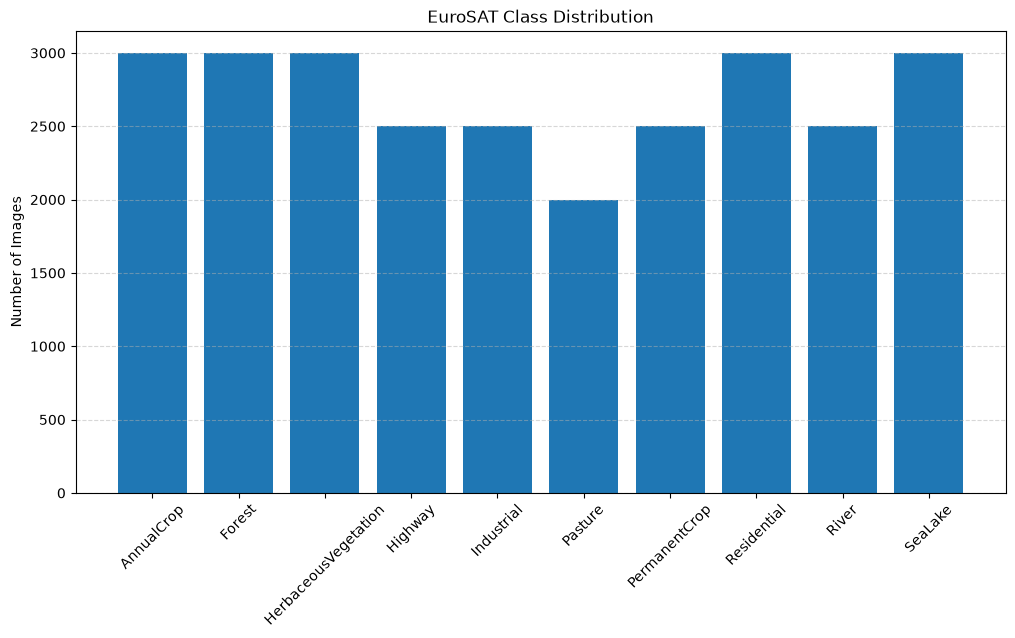

In [6]:
plt.figure(figsize=(12,6))

plt.bar(class_counts.keys(),
        class_counts.values())

plt.xticks(rotation=45)

plt.ylabel("Number of Images")

plt.title("EuroSAT Class Distribution")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

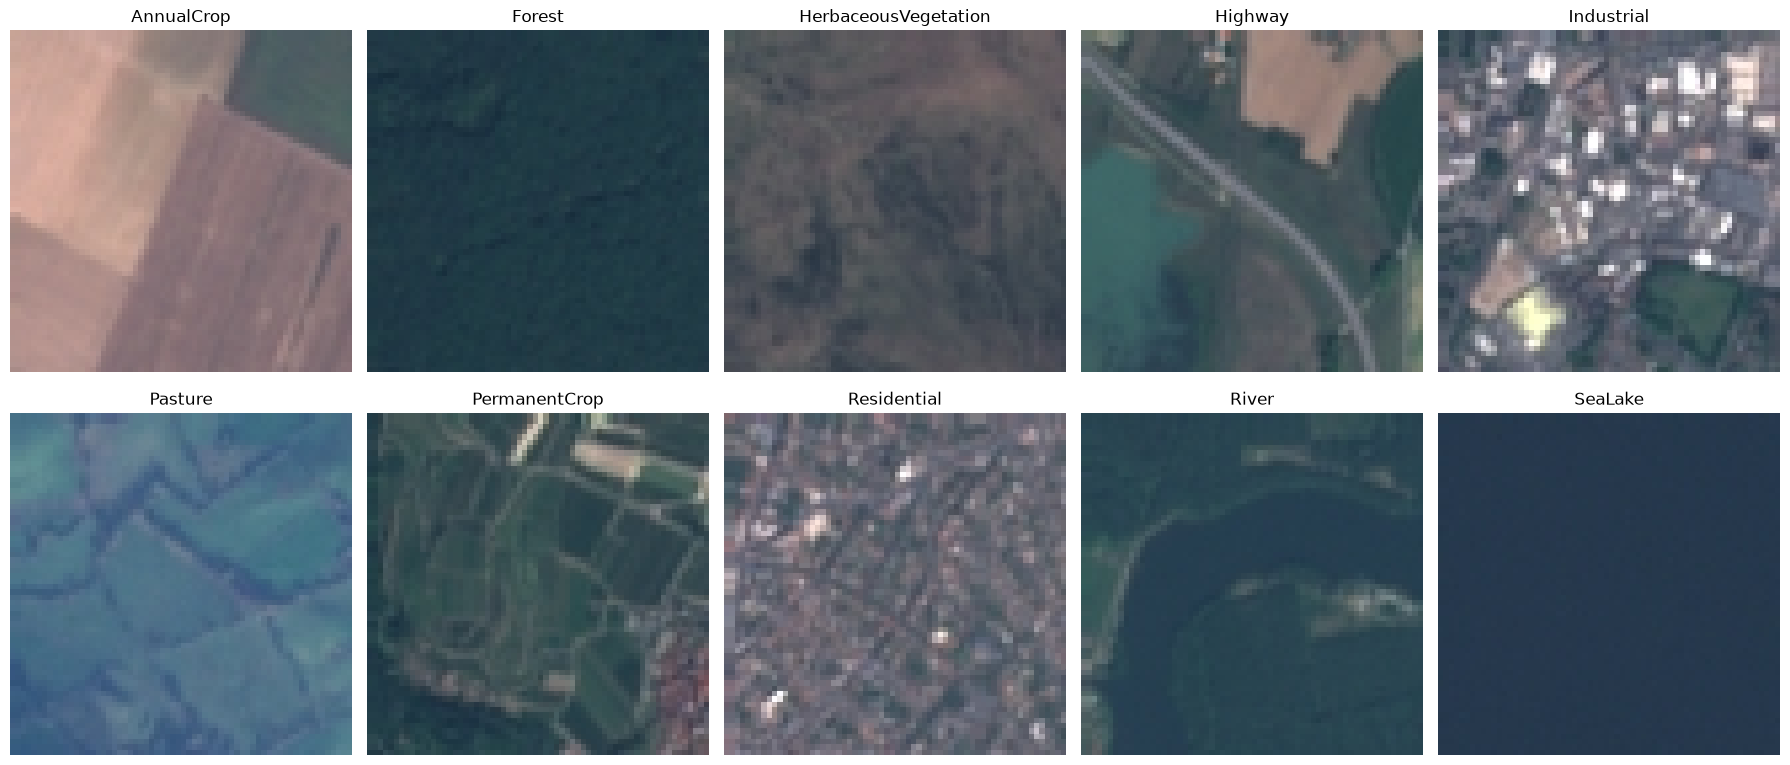

In [7]:
fig, axes = plt.subplots(2,5, figsize=(18,8))

axes = axes.flatten()

for idx, cls in enumerate(eurosat_dataset.classes):

    folder = os.path.join(EUROSAT_PATH, cls)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    img = Image.open(image_path)

    axes[idx].imshow(img)

    axes[idx].set_title(cls)

    axes[idx].axis("off")

plt.tight_layout()

plt.show()

In [8]:
image_sizes = []

for cls in eurosat_dataset.classes:

    folder = os.path.join(EUROSAT_PATH, cls)

    img_path = os.path.join(folder,
                            os.listdir(folder)[0])

    img = Image.open(img_path)

    image_sizes.append(img.size)

image_sizes

[(64, 64),
 (64, 64),
 (64, 64),
 (64, 64),
 (64, 64),
 (64, 64),
 (64, 64),
 (64, 64),
 (64, 64),
 (64, 64)]

In [9]:
print("="*50)
print("Dataset Statistics")
print("="*50)

print(f"Total Images : {len(eurosat_dataset)}")

print(f"Total Classes: {len(eurosat_dataset.classes)}")

print(f"Image Size   : {image_sizes[0]}")

print(f"Average Images/Class : {len(eurosat_dataset)//len(eurosat_dataset.classes)}")

Dataset Statistics
Total Images : 27000
Total Classes: 10
Image Size   : (64, 64)
Average Images/Class : 2700
